# Processamento de Linguagem Natural (PLN)

PLN é uma área da ciência de dados que estuda como transformar textos em informação estruturada. Neste notebook, aplicamos essas técnicas sobre notícias de esporte coletadas do site da **Agência Minas** via webscraping. Com as análises a seguir, conseguimos identificar os temas mais recorrentes, as palavras mais frequentes e preparar os textos para modelos de aprendizado de máquina.

In [1]:
import json
from pathlib import Path

import pandas as pd

noticias = []

df = pd.read_csv("../../dados/noticias_agencia_minas.csv")

print(f"Antes: {len(df)} noticias")

df = df.drop_duplicates(subset="url").reset_index(drop=True)

print(f"Depois: {len(df)} noticias")

df.head()

Antes: 328 noticias
Depois: 326 noticias


,titulo,subtitulo,descricao,temas,data,ano_mes,ano,mes,hora,turno,n_temas,tamanho_texto,n_palavras_titulo,n_relacionadas,url
0,Governo de Minas participa de premiação em eta...,Jogos Escolares de Minas Gerais voltaram a reg...,"O governador de Minas Gerais, Mateus Simões,...","['Social', 'Esportes', 'Governador']",2026-05-24 11:20:00-03:00,2026-05,2026,5,11,Manhã,3,578,14,4,https://www.agenciaminas.mg.gov.br/noticia/gov...
1,Governo de Minas inaugura nova quadra poliespo...,"Investimento de R$ 1,4 milhão amplia infraestr...","O governador de Minas Gerais, Mateus Simões, i...","['Educação', 'Governo', 'Governador', 'Esportes']",2026-05-20 18:30:00-03:00,2026-05,2026,5,18,Noite,4,809,13,4,https://www.agenciaminas.mg.gov.br/noticia/gov...
2,Prêmio do Esporte Mineiro chega à 9ª edição e ...,"Com mais de 651 mil votos na votação popular, ...",O Prêmio do Esporte Mineiro (PEM) chega à sua ...,"['Social', 'Esportes']",2025-12-18 14:30:00-03:00,2025-12,2025,12,14,Tarde,2,410,15,4,https://www.agenciaminas.mg.gov.br/noticia/pre...
3,Governo de Minas distribui kits esportivos par...,"Ao todo, mais de R$ 3,5 milhões já foram inves...",Prefeitos e vice-prefeitos das cidades de Bom ...,['Esportes'],2024-07-03 17:00:00-03:00,2024-07,2024,7,17,Tarde,1,443,12,4,https://www.agenciaminas.mg.gov.br/noticia/gov...
4,Times de Comunidades Terapêuticas fazem histór...,"Estrutura profissional, realização e alegria m...","O time de futebol Cerdad, de Santa Luzia, é o ...","['Social', 'Esportes', 'Segurança']",2024-06-28 18:30:00-03:00,2024-06,2024,6,18,Noite,3,635,13,4,https://www.agenciaminas.mg.gov.br/noticia/tim...


## Carregando os dados

O arquivo `noticias_agencia_minas.csv` contém as notícias de esporte coletadas da Agência Minas. Após carregar, removemos duplicatas com base na URL para garantir que cada notícia seja única.

## Passos da análise

A preparação dos textos das notícias será feita em etapas:

1. Limpar os textos (minúsculas, remoção de acentos e pontuação).
2. Remover palavras muito comuns (stopwords).
3. Criar uma representação Bag of Words para cada coluna textual.
4. Realizar análises de frequência das palavras.
5. Montar o DataFrame final para análises posteriores.

## 1. Limpeza básica

A função abaixo limpa o texto de cada notícia:

- `wordpunct_tokenize` separa o texto em palavras e pontuação.
- `texto.lower()` coloca tudo em minúsculas.
- `unidecode(texto)` substitui letras acentuadas por letras sem acento.
- `token.isalnum()` mantém apenas letras e números, removendo pontuação.
- `" ".join(tokens)` reconstrói o texto limpo a partir dos tokens.

Exemplo: `"Atlético vence na Copa!"` vira `"atletico vence na copa"`.

In [2]:
from nltk.tokenize import wordpunct_tokenize
from unidecode import unidecode


def limpar_descricao(descricao):
    descricao = descricao.lower()
    descricao = unidecode(descricao)
    tokens = wordpunct_tokenize(descricao)
    tokens = [token for token in tokens if token.isalnum()]
    return " ".join(tokens)


df["descricao_limpo"] = df["descricao"].apply(limpar_descricao)

df[["descricao", "descricao_limpo"]].head()

,descricao,descricao_limpo
0,"O governador de Minas Gerais, Mateus Simões,...",o governador de minas gerais mateus simoes par...
1,"O governador de Minas Gerais, Mateus Simões, i...",o governador de minas gerais mateus simoes ina...
2,O Prêmio do Esporte Mineiro (PEM) chega à sua ...,o premio do esporte mineiro pem chega a sua 9a...
3,Prefeitos e vice-prefeitos das cidades de Bom ...,prefeitos e vice prefeitos das cidades de bom ...
4,"O time de futebol Cerdad, de Santa Luzia, é o ...",o time de futebol cerdad de santa luzia e o ca...


## 2. Removendo stopwords

Stopwords são palavras muito comuns como `a`, `o`, `de`, `para` e `que`. Elas aparecem em praticamente todas as notícias, mas contribuem pouco para identificar o assunto de cada uma.

- `stopwords.words("portuguese")` carrega a lista de stopwords em português.
- `token not in stopwords_pt` filtra as palavras muito comuns.
- `.str.join(" ")` reconstrói o texto sem as stopwords.

Exemplo: `"o atletico venceu no estadio"` vira `["atletico", "venceu", "estadio"]`.

In [3]:
import nltk

from nltk.corpus import stopwords


nltk.download("stopwords", quiet=True)

stopwords_pt = stopwords.words("portuguese")
stopwords_pt = [unidecode(palavra) for palavra in stopwords_pt]
stopwords_pt = set(stopwords_pt)


def remover_stopwords(descricao):
    tokens = descricao.split()
    tokens = [token for token in tokens if token not in stopwords_pt]
    return tokens


df["tokens_sem_stopwords"] = df["descricao_limpo"].apply(remover_stopwords)
df["descricao_sem_stopwords"] = df["tokens_sem_stopwords"].str.join(" ")

df[["descricao_limpo", "tokens_sem_stopwords", "descricao_sem_stopwords"]].head()

,descricao_limpo,tokens_sem_stopwords,descricao_sem_stopwords
0,o governador de minas gerais mateus simoes par...,"[governador, minas, gerais, mateus, simoes, pa...",governador minas gerais mateus simoes particip...
1,o governador de minas gerais mateus simoes ina...,"[governador, minas, gerais, mateus, simoes, in...",governador minas gerais mateus simoes inauguro...
2,o premio do esporte mineiro pem chega a sua 9a...,"[premio, esporte, mineiro, pem, chega, 9a, edi...",premio esporte mineiro pem chega 9a edicao 202...
3,prefeitos e vice prefeitos das cidades de bom ...,"[prefeitos, vice, prefeitos, cidades, bom, jes...",prefeitos vice prefeitos cidades bom jesus amp...
4,o time de futebol cerdad de santa luzia e o ca...,"[time, futebol, cerdad, santa, luzia, campeao,...",time futebol cerdad santa luzia campeao i camp...


## 3. Bag of Words

O Bag of Words representa cada notícia como um vetor de contagens: cada coluna é uma palavra do vocabulário e o valor indica quantas vezes ela aparece naquela notícia.

Exemplo: `"minas ganhou minas"` teria `minas = 2` e `ganhou = 1`.

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
matriz_bow = vectorizer.fit_transform(df["descricao_sem_stopwords"])

df_bow = pd.DataFrame(
    matriz_bow.toarray(),
    columns=vectorizer.get_feature_names_out()
)

df_bow.head()

,01,04,10,100,11,12,120,13,14,15,...,votacao,vulnerabilidade,vulneraveis,willian,xadrez,xxvii,yago,youtube,zema,zona
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Removendo colunas com números

Após gerar o Bag of Words, removemos colunas cujo nome contém algum dígito. Isso elimina tokens como anos, placares e outros números que não agregam valor semântico à análise.

In [5]:
colunas_com_numeros = [col for col in df_bow.columns if any(char.isdigit() for char in col)]

df_bow = df_bow.drop(columns=colunas_com_numeros)

print(f"{len(colunas_com_numeros)} colunas removidas")
df_bow.head()

72 colunas removidas


,abastecimento,aberta,abertas,aberto,abertura,abrangendo,abre,abriu,acaba,acao,...,votacao,vulnerabilidade,vulneraveis,willian,xadrez,xxvii,yago,youtube,zema,zona
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.columns

Index(['titulo', 'subtitulo', 'descricao', 'temas', 'data', 'ano_mes', 'ano',
       'mes', 'hora', 'turno', 'n_temas', 'tamanho_texto', 'n_palavras_titulo',
       'n_relacionadas', 'url', 'descricao_limpo', 'tokens_sem_stopwords',
       'descricao_sem_stopwords'],
      dtype='object')

### Construindo o DataFrame intermediário

Aqui combinamos os metadados das notícias (título, data, temas, etc.) com as colunas do Bag of Words da descrição. Para evitar conflito de nomes, as colunas do Bag of Words recebem o prefixo `bow_`.

> **Nota:** este é um DataFrame intermediário. O DataFrame final (`df_final_completo`), com os Bag of Words de todas as colunas textuais, é construído mais adiante.

In [7]:
metadados = df[['titulo', 'subtitulo', 'descricao', 'temas', 'data', 'ano_mes', 'ano',
       'mes', 'hora', 'turno', 'n_temas', 'tamanho_texto', 'n_palavras_titulo',
       'n_relacionadas', 'url']].reset_index(drop=True)
bow_com_prefixo = df_bow.add_prefix("bow_").reset_index(drop=True)

df_final = pd.concat([metadados, bow_com_prefixo], axis=1)

df_final.head()

,titulo,subtitulo,descricao,temas,data,ano_mes,ano,mes,hora,turno,...,bow_votacao,bow_vulnerabilidade,bow_vulneraveis,bow_willian,bow_xadrez,bow_xxvii,bow_yago,bow_youtube,bow_zema,bow_zona
0,Governo de Minas participa de premiação em eta...,Jogos Escolares de Minas Gerais voltaram a reg...,"O governador de Minas Gerais, Mateus Simões,...","['Social', 'Esportes', 'Governador']",2026-05-24 11:20:00-03:00,2026-05,2026,5,11,Manhã,...,0,0,0,0,0,0,0,0,0,0
1,Governo de Minas inaugura nova quadra poliespo...,"Investimento de R$ 1,4 milhão amplia infraestr...","O governador de Minas Gerais, Mateus Simões, i...","['Educação', 'Governo', 'Governador', 'Esportes']",2026-05-20 18:30:00-03:00,2026-05,2026,5,18,Noite,...,0,0,0,0,0,0,0,0,0,0
2,Prêmio do Esporte Mineiro chega à 9ª edição e ...,"Com mais de 651 mil votos na votação popular, ...",O Prêmio do Esporte Mineiro (PEM) chega à sua ...,"['Social', 'Esportes']",2025-12-18 14:30:00-03:00,2025-12,2025,12,14,Tarde,...,0,0,0,0,0,0,0,0,0,0
3,Governo de Minas distribui kits esportivos par...,"Ao todo, mais de R$ 3,5 milhões já foram inves...",Prefeitos e vice-prefeitos das cidades de Bom ...,['Esportes'],2024-07-03 17:00:00-03:00,2024-07,2024,7,17,Tarde,...,0,0,0,0,0,0,0,0,0,0
4,Times de Comunidades Terapêuticas fazem histór...,"Estrutura profissional, realização e alegria m...","O time de futebol Cerdad, de Santa Luzia, é o ...","['Social', 'Esportes', 'Segurança']",2024-06-28 18:30:00-03:00,2024-06,2024,6,18,Noite,...,0,0,0,0,0,0,0,0,0,0


## Análise exploratória — Descrição

Com o Bag of Words da descrição montado, fazemos uma análise inicial de frequência: quais palavras aparecem mais nas notícias de esporte da Agência Minas, quantas aparecem em poucos documentos e quantas palavras únicas cada notícia contém.

In [8]:
colunas_bow = [coluna for coluna in df_final.columns if coluna.startswith("bow_")]

frequencia_palavras = df_final[colunas_bow].sum().sort_values(ascending=False)

print(f"Total de palavras diferentes: {len(frequencia_palavras)}")

frequencia_palavras.head(10)

Total de palavras diferentes: 1318


bow_minas              210
bow_gerais             122
bow_jogos               96
bow_estado              92
bow_feira               87
bow_social              78
bow_secretaria          74
bow_desenvolvimento     69
bow_sedese              64
bow_escolares           62
dtype: int64

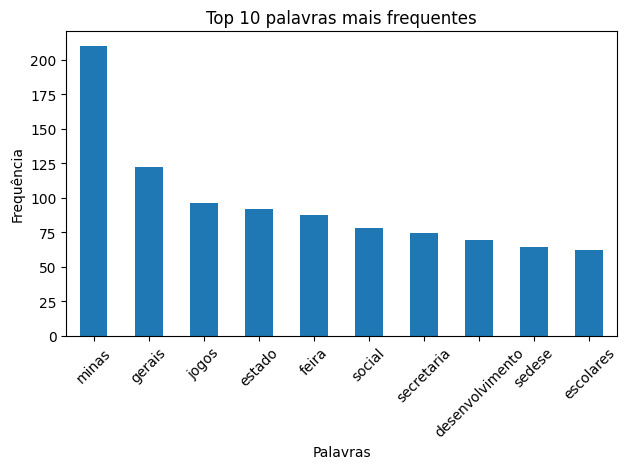

In [9]:
# gráfico das 10 palavras mais recentes 
import matplotlib.pyplot as plt

top10 = frequencia_palavras.head(10)
top10.index = top10.index.str.replace('bow_', '', regex=False)

plt.figure()
top10.plot(kind='bar')
plt.title('Top 10 palavras mais frequentes')
plt.xlabel('Palavras')
plt.ylabel('Frequência')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
frequencia_palavras.tail(10)

bow_vivem         1
bow_acontecera    1
bow_acompanhou    1
bow_acompanhar    1
bow_acirradas     1
bow_acidente      1
bow_achava        1
bow_acesso        1
bow_acervo        1
bow_acende        1
dtype: int64

In [11]:
documentos_por_palavra = (df_final[colunas_bow] > 0).sum().sort_values(ascending=False)
documentos_por_palavra.index = documentos_por_palavra.index.str.replace("bow_", "", regex=False)

documentos_por_palavra.head(10)

minas              184
gerais             119
jogos               94
estado              89
feira               86
social              78
secretaria          74
desenvolvimento     67
escolares           61
sedese              61
dtype: int64

In [12]:
df_final["palavras_unicas"] = (df_final[colunas_bow] > 0).sum(axis=1)

df_final[["titulo", "palavras_unicas"]].sort_values("palavras_unicas", ascending=True).head(10)

,titulo,palavras_unicas
82,"Etapa Estadual do Jemg reúne 6,4 mil estudante...",9
198,Oficinas de esportes paralímpicos mobilizam cr...,9
322,Governo de Minas apresenta ações esportivas e ...,10
270,"Vitória Miranda, atleta patrocinada pela Copas...",10
91,Sedese lança edital para realização do Jimi Pa...,10
177,Prorrogadas inscrições para o JimiVirtual até ...,10
53,Fórum de Temáticas Esportivas completa ciclo d...,10
212,Mineirinho vira o palco do Arraial de Belô pel...,10
84,Bolsa Atleta e Bolsa Técnico estão com inscriç...,10
136,Prorrogado prazo para municípios que querem se...,10


## TF-IDF

O TF-IDF (Term Frequency–Inverse Document Frequency) é uma medida que pondera a importância de cada palavra em uma notícia em relação ao conjunto inteiro. Palavras muito comuns a todas as notícias recebem peso baixo; palavras específicas de poucas notícias recebem peso alto.

O cálculo é feito manualmente em três etapas:

1. **TF** — frequência relativa do termo na notícia (contagem dividida pelo total de palavras).
2. **IDF** — log do número total de notícias dividido pelo número de notícias que contêm o termo.
3. **TF-IDF** — produto das duas medidas anteriores.

> O cálculo parte das colunas `bow_` do `df_final` (Bag of Words da descrição).

In [13]:
# Separar apenas as colunas bow_ do df_final.
cols_bow = [col for col in df_final.columns if col.startswith('bow_')]
df_bow = df_final[cols_bow].copy()

# Remover o prefixo bow_ dos nomes das colunas, para trabalhar diretamente com as palavras.
df_bow.columns = [col[4:] for col in df_bow.columns]

df_bow.head()

,abastecimento,aberta,abertas,aberto,abertura,abrangendo,abre,abriu,acaba,acao,...,votacao,vulnerabilidade,vulneraveis,willian,xadrez,xxvii,yago,youtube,zema,zona
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
# Calcular o total de palavras de cada noticia somando as linhas da matriz.
total_palavras = df_bow.sum(axis=1)

# Calcular o TF dividindo cada valor da linha pelo total da propria linha.
df_tf = df_bow.div(total_palavras, axis=0)

df_tf.head()

,abastecimento,aberta,abertas,aberto,abertura,abrangendo,abre,abriu,acaba,acao,...,votacao,vulnerabilidade,vulneraveis,willian,xadrez,xxvii,yago,youtube,zema,zona
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
# Calcular em quantas noticias cada palavra aparece.
doc_freq = (df_bow > 0).sum(axis=0)

import numpy as np

# Calcular o IDF
N = df_bow.shape[0]
idf = np.log(N / doc_freq)

df_idf = pd.DataFrame({
    "documentos_com_o_termo": doc_freq,
    "idf": idf
}).sort_values("idf", ascending=False)

df_idf.head(10)

,documentos_com_o_termo,idf
youtube,1,5.786897
abastecimento,1,5.786897
yago,1,5.786897
visitou,1,5.786897
visitarem,1,5.786897
virtude,1,5.786897
vindas,1,5.786897
video,1,5.786897
vicosa,1,5.786897
ai,1,5.786897


In [16]:
df_idf.tail(10)

,documentos_com_o_termo,idf
sedese,61,1.676024
escolares,61,1.676024
desenvolvimento,67,1.582205
secretaria,74,1.482832
social,78,1.430189
feira,86,1.332550
estado,89,1.298261
jogos,94,1.243603
gerais,119,1.007774
minas,184,0.571962


In [17]:
# Multiplicar a matriz de TF pelo vetor de IDF.
df_tfidf = df_tf.mul(idf, axis=1)

In [18]:
df_tfidf.head()

,abastecimento,aberta,abertas,aberto,abertura,abrangendo,abre,abriu,acaba,acao,...,votacao,vulnerabilidade,vulneraveis,willian,xadrez,xxvii,yago,youtube,zema,zona
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [44]:
# ✅ Correto — palavras mais importantes de uma notícia específica
noticia = 12  # escolha o índice que quiser

print(df_final.loc[noticia, "titulo"])
df_tfidf.loc[noticia].sort_values(ascending=False).head(10)

Jimi Futsal: volta da competição consagra o esporte no interior de Minas Gerais


comemoram     0.413350
azul          0.413350
pedra         0.413350
vencedores    0.413350
feminino      0.363839
sucesso       0.334878
volta         0.314329
futsal        0.298390
jimi          0.285367
interior      0.215308
Name: 12, dtype: float64

In [20]:
# Adiciona prefixo tfidf_ e monta o DataFrame final de TF-IDF
tfidf_com_prefixo = df_tfidf.add_prefix("tfidf_").reset_index(drop=True)

df_final_tfidf = pd.concat([metadados, tfidf_com_prefixo], axis=1)

df_final_tfidf.head()


,titulo,subtitulo,descricao,temas,data,ano_mes,ano,mes,hora,turno,...,tfidf_votacao,tfidf_vulnerabilidade,tfidf_vulneraveis,tfidf_willian,tfidf_xadrez,tfidf_xxvii,tfidf_yago,tfidf_youtube,tfidf_zema,tfidf_zona
0,Governo de Minas participa de premiação em eta...,Jogos Escolares de Minas Gerais voltaram a reg...,"O governador de Minas Gerais, Mateus Simões,...","['Social', 'Esportes', 'Governador']",2026-05-24 11:20:00-03:00,2026-05,2026,5,11,Manhã,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Governo de Minas inaugura nova quadra poliespo...,"Investimento de R$ 1,4 milhão amplia infraestr...","O governador de Minas Gerais, Mateus Simões, i...","['Educação', 'Governo', 'Governador', 'Esportes']",2026-05-20 18:30:00-03:00,2026-05,2026,5,18,Noite,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Prêmio do Esporte Mineiro chega à 9ª edição e ...,"Com mais de 651 mil votos na votação popular, ...",O Prêmio do Esporte Mineiro (PEM) chega à sua ...,"['Social', 'Esportes']",2025-12-18 14:30:00-03:00,2025-12,2025,12,14,Tarde,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Governo de Minas distribui kits esportivos par...,"Ao todo, mais de R$ 3,5 milhões já foram inves...",Prefeitos e vice-prefeitos das cidades de Bom ...,['Esportes'],2024-07-03 17:00:00-03:00,2024-07,2024,7,17,Tarde,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Times de Comunidades Terapêuticas fazem histór...,"Estrutura profissional, realização e alegria m...","O time de futebol Cerdad, de Santa Luzia, é o ...","['Social', 'Esportes', 'Segurança']",2024-06-28 18:30:00-03:00,2024-06,2024,6,18,Noite,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Bag of Words — Título

Repetimos o mesmo processo de limpeza e geração de Bag of Words para a coluna `titulo`. Isso nos permitirá analisar quais palavras aparecem com mais frequência nos títulos das notícias de esporte.

In [21]:
from nltk.tokenize import wordpunct_tokenize
from unidecode import unidecode


def limpar_titulo(titulo):
    titulo = titulo.lower()
    titulo = unidecode(titulo)
    tokens = wordpunct_tokenize(titulo)
    tokens = [token for token in tokens if token.isalnum()]
    return " ".join(tokens)


df["titulo_limpo"] = df["titulo"].apply(limpar_titulo)

df[["titulo", "titulo_limpo"]].head()

,titulo,titulo_limpo
0,Governo de Minas participa de premiação em eta...,governo de minas participa de premiacao em eta...
1,Governo de Minas inaugura nova quadra poliespo...,governo de minas inaugura nova quadra poliespo...
2,Prêmio do Esporte Mineiro chega à 9ª edição e ...,premio do esporte mineiro chega a 9a edicao e ...
3,Governo de Minas distribui kits esportivos par...,governo de minas distribui kits esportivos par...
4,Times de Comunidades Terapêuticas fazem histór...,times de comunidades terapeuticas fazem histor...


In [22]:
df["tokens_titulo"] = df["titulo_limpo"].apply(remover_stopwords)
df["titulo_sem_stopwords"] = df["tokens_titulo"].str.join(" ")

df[["titulo_limpo", "tokens_titulo", "titulo_sem_stopwords"]].head()

,titulo_limpo,tokens_titulo,titulo_sem_stopwords
0,governo de minas participa de premiacao em eta...,"[governo, minas, participa, premiacao, etapa, ...",governo minas participa premiacao etapa jemg s...
1,governo de minas inaugura nova quadra poliespo...,"[governo, minas, inaugura, nova, quadra, polie...",governo minas inaugura nova quadra poliesporti...
2,premio do esporte mineiro chega a 9a edicao e ...,"[premio, esporte, mineiro, chega, 9a, edicao, ...",premio esporte mineiro chega 9a edicao celebra...
3,governo de minas distribui kits esportivos par...,"[governo, minas, distribui, kits, esportivos, ...",governo minas distribui kits esportivos munici...
4,times de comunidades terapeuticas fazem histor...,"[times, comunidades, terapeuticas, fazem, hist...",times comunidades terapeuticas fazem historia ...


In [23]:
vectorizer_titulo = CountVectorizer()
matriz_bow_titulo = vectorizer_titulo.fit_transform(df["titulo_sem_stopwords"])

df_bow_titulo = pd.DataFrame(
    matriz_bow_titulo.toarray(),
    columns=vectorizer_titulo.get_feature_names_out()
)

df_bow_titulo.head()

,10,100,103,11,12,130,14,15,16,17,...,voltadas,voltado,voltados,voltara,votacao,vou,vulneravel,xadrez,xxvii,zona
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
colunas_num_titulo = [col for col in df_bow_titulo.columns if any(char.isdigit() for char in col)]
df_bow_titulo = df_bow_titulo.drop(columns=colunas_num_titulo)

print(f"{len(colunas_num_titulo)} colunas removidas")

47 colunas removidas


## Bag of Words — Subtítulo

Aplicamos o mesmo pipeline à coluna `subtitulo`. A função `limpar_texto` é generalizada para funcionar em qualquer campo textual.

In [25]:
def limpar_texto(texto):
    """Limpa um texto: minúsculas, remove acentos, tokeniza e filtra alfanuméricos."""
    texto = str(texto).lower()
    texto = unidecode(texto)
    tokens = wordpunct_tokenize(texto)
    tokens = [token for token in tokens if token.isalnum()]
    return " ".join(tokens)

df["subtitulo_limpo"] = df["subtitulo"].apply(limpar_texto)
df[["subtitulo", "subtitulo_limpo"]].head()

,subtitulo,subtitulo_limpo
0,Jogos Escolares de Minas Gerais voltaram a reg...,jogos escolares de minas gerais voltaram a reg...
1,"Investimento de R$ 1,4 milhão amplia infraestr...",investimento de r 1 4 milhao amplia infraestru...
2,"Com mais de 651 mil votos na votação popular, ...",com mais de 651 mil votos na votacao popular v...
3,"Ao todo, mais de R$ 3,5 milhões já foram inves...",ao todo mais de r 3 5 milhoes ja foram investi...
4,"Estrutura profissional, realização e alegria m...",estrutura profissional realizacao e alegria ma...


In [26]:
df["tokens_subtitulo"] = df["subtitulo_limpo"].apply(remover_stopwords)
df["subtitulo_sem_stopwords"] = df["tokens_subtitulo"].str.join(" ")

df[["subtitulo_limpo", "tokens_subtitulo", "subtitulo_sem_stopwords"]].head()

,subtitulo_limpo,tokens_subtitulo,subtitulo_sem_stopwords
0,jogos escolares de minas gerais voltaram a reg...,"[jogos, escolares, minas, gerais, voltaram, re...",jogos escolares minas gerais voltaram registra...
1,investimento de r 1 4 milhao amplia infraestru...,"[investimento, r, 1, 4, milhao, amplia, infrae...",investimento r 1 4 milhao amplia infraestrutur...
2,com mais de 651 mil votos na votacao popular v...,"[651, mil, votos, votacao, popular, vencedores...",651 mil votos votacao popular vencedores conhe...
3,ao todo mais de r 3 5 milhoes ja foram investi...,"[todo, r, 3, 5, milhoes, investidos, compra, e...",todo r 3 5 milhoes investidos compra entrega m...
4,estrutura profissional realizacao e alegria ma...,"[estrutura, profissional, realizacao, alegria,...",estrutura profissional realizacao alegria marc...


In [27]:
vectorizer_subtitulo = CountVectorizer()
matriz_bow_subtitulo = vectorizer_subtitulo.fit_transform(df["subtitulo_sem_stopwords"])

df_bow_subtitulo = pd.DataFrame(
    matriz_bow_subtitulo.toarray(),
    columns=vectorizer_subtitulo.get_feature_names_out()
)

df_bow_subtitulo.head()

,05,10,100,101,11,11h,12,121,12h,13,...,voltaram,votacao,votos,warner,xadrez,xcc,yago,youtube,zema,zona
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
colunas_num_subtitulo = [col for col in df_bow_subtitulo.columns if any(char.isdigit() for char in col)]
df_bow_subtitulo = df_bow_subtitulo.drop(columns=colunas_num_subtitulo)

print(f"{len(colunas_num_subtitulo)} colunas removidas")

86 colunas removidas


## Bag of Words — Temas

A coluna `temas` armazena as categorias de cada notícia como uma lista (ex: `['Esporte', 'Futebol']`). Precisamos primeiro converter essa lista em texto plano antes de aplicar o pipeline de limpeza.

In [29]:
import ast


def extrair_temas(temas_str):
    """Converte string de lista em texto plano com os temas separados por espaço."""
    try:
        lista = ast.literal_eval(str(temas_str))
        return " ".join(lista)
    except Exception:
        return str(temas_str)


df["temas_texto"] = df["temas"].apply(extrair_temas)
df[["temas", "temas_texto"]].head()

,temas,temas_texto
0,"['Social', 'Esportes', 'Governador']",Social Esportes Governador
1,"['Educação', 'Governo', 'Governador', 'Esportes']",Educação Governo Governador Esportes
2,"['Social', 'Esportes']",Social Esportes
3,['Esportes'],Esportes
4,"['Social', 'Esportes', 'Segurança']",Social Esportes Segurança


In [30]:
df["temas_limpo"] = df["temas_texto"].apply(limpar_texto)
df["tokens_temas"] = df["temas_limpo"].apply(remover_stopwords)
df["temas_sem_stopwords"] = df["tokens_temas"].str.join(" ")

df[["temas_texto", "temas_limpo", "temas_sem_stopwords"]].head()

,temas_texto,temas_limpo,temas_sem_stopwords
0,Social Esportes Governador,social esportes governador,social esportes governador
1,Educação Governo Governador Esportes,educacao governo governador esportes,educacao governo governador esportes
2,Social Esportes,social esportes,social esportes
3,Esportes,esportes,esportes
4,Social Esportes Segurança,social esportes seguranca,social esportes seguranca


In [31]:
vectorizer_temas = CountVectorizer()
matriz_bow_temas = vectorizer_temas.fit_transform(df["temas_sem_stopwords"])

df_bow_temas = pd.DataFrame(
    matriz_bow_temas.toarray(),
    columns=vectorizer_temas.get_feature_names_out()
)
df_bow_temas.head()

,ambiente,brumadinho,consciente,coronavirus,cultura,desenvolvimento,direitos,economico,educacao,esportes,...,humanos,infraestrutura,meio,minas,pesquisa,saude,seguranca,social,trabalho,turismo
0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,1,0,0


In [32]:
colunas_num_temas = [col for col in df_bow_temas.columns if any(char.isdigit() for char in col)]
df_bow_temas = df_bow_temas.drop(columns=colunas_num_temas)

print(f"{len(colunas_num_temas)} colunas removidas")

0 colunas removidas


## DataFrame final

Aqui consolidamos todos os Bag of Words em um único DataFrame, usando prefixos para diferenciar a origem de cada coluna:

- `bow_desc_` → palavras da descrição
- `bow_tit_` → palavras do título
- `bow_sub_` → palavras do subtítulo
- `bow_tema_` → palavras dos temas


In [33]:
metadados = df[[
    "titulo", "subtitulo", "descricao", "temas", "data", "ano_mes", "ano",
    "mes", "hora", "turno", "n_temas", "tamanho_texto", "n_palavras_titulo",
    "n_relacionadas", "url"
]].reset_index(drop=True)

bow_desc_pref  = df_bow.add_prefix("bow_desc_").reset_index(drop=True)
bow_tit_pref   = df_bow_titulo.add_prefix("bow_tit_").reset_index(drop=True)
bow_sub_pref   = df_bow_subtitulo.add_prefix("bow_sub_").reset_index(drop=True)
bow_tema_pref  = df_bow_temas.add_prefix("bow_tema_").reset_index(drop=True)

df_final_completo = pd.concat(
    [metadados, bow_desc_pref, bow_tit_pref, bow_sub_pref, bow_tema_pref],
    axis=1
)

df_final_completo.head()

,titulo,subtitulo,descricao,temas,data,ano_mes,ano,mes,hora,turno,...,bow_tema_humanos,bow_tema_infraestrutura,bow_tema_meio,bow_tema_minas,bow_tema_pesquisa,bow_tema_saude,bow_tema_seguranca,bow_tema_social,bow_tema_trabalho,bow_tema_turismo
0,Governo de Minas participa de premiação em eta...,Jogos Escolares de Minas Gerais voltaram a reg...,"O governador de Minas Gerais, Mateus Simões,...","['Social', 'Esportes', 'Governador']",2026-05-24 11:20:00-03:00,2026-05,2026,5,11,Manhã,...,0,0,0,0,0,0,0,1,0,0
1,Governo de Minas inaugura nova quadra poliespo...,"Investimento de R$ 1,4 milhão amplia infraestr...","O governador de Minas Gerais, Mateus Simões, i...","['Educação', 'Governo', 'Governador', 'Esportes']",2026-05-20 18:30:00-03:00,2026-05,2026,5,18,Noite,...,0,0,0,0,0,0,0,0,0,0
2,Prêmio do Esporte Mineiro chega à 9ª edição e ...,"Com mais de 651 mil votos na votação popular, ...",O Prêmio do Esporte Mineiro (PEM) chega à sua ...,"['Social', 'Esportes']",2025-12-18 14:30:00-03:00,2025-12,2025,12,14,Tarde,...,0,0,0,0,0,0,0,1,0,0
3,Governo de Minas distribui kits esportivos par...,"Ao todo, mais de R$ 3,5 milhões já foram inves...",Prefeitos e vice-prefeitos das cidades de Bom ...,['Esportes'],2024-07-03 17:00:00-03:00,2024-07,2024,7,17,Tarde,...,0,0,0,0,0,0,0,0,0,0
4,Times de Comunidades Terapêuticas fazem histór...,"Estrutura profissional, realização e alegria m...","O time de futebol Cerdad, de Santa Luzia, é o ...","['Social', 'Esportes', 'Segurança']",2024-06-28 18:30:00-03:00,2024-06,2024,6,18,Noite,...,0,0,0,0,0,0,1,1,0,0


## Análise descritiva

Com o DataFrame final montado, analisamos a frequência das palavras em cada campo textual das notícias da Agência Minas.

### Palavras mais frequentes — Título

Quais são as palavras que mais aparecem nos títulos das notícias de esporte?

In [34]:
colunas_bow_titulo = [coluna for coluna in df_final_completo.columns if coluna.startswith("bow_tit_")]

frequencia_palavras = df_final_completo[colunas_bow_titulo].sum().sort_values(ascending=False)

print(f"Total de palavras diferentes: {len(frequencia_palavras)}")

frequencia_palavras.head(10)

Total de palavras diferentes: 856


bow_tit_minas        146
bow_tit_jogos         77
bow_tit_governo       73
bow_tit_escolares     58
bow_tit_gerais        53
bow_tit_esporte       45
bow_tit_etapa         29
bow_tit_atletas       28
bow_tit_estado        28
bow_tit_estadual      27
dtype: int64

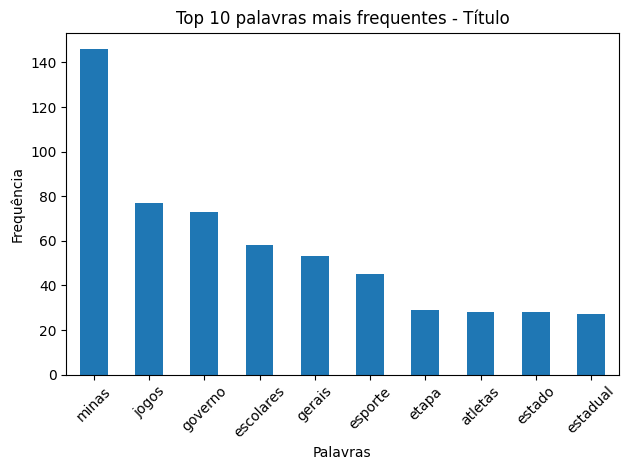

In [35]:
top10_titulo = frequencia_palavras.head(10)
top10_titulo.index = top10_titulo.index.str.replace('bow_tit_', '', regex=False)

import matplotlib.pyplot as plt

plt.figure()
top10_titulo.plot(kind='bar')

plt.title('Top 10 palavras mais frequentes - Título')
plt.xlabel('Palavras')
plt.ylabel('Frequência')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Palavras mais frequentes — Subtítulo

Quais são as palavras mais recorrentes nos subtítulos das notícias?

In [36]:
colunas_bow_subtitulo = [coluna for coluna in df_final_completo.columns if coluna.startswith("bow_sub_")]

frequencia_palavras = df_final_completo[colunas_bow_subtitulo].sum().sort_values(ascending=False)

print(f"Total de palavras diferentes: {len(frequencia_palavras)}")

frequencia_palavras.head(10)

Total de palavras diferentes: 1344


bow_sub_minas         51
bow_sub_competicao    50
bow_sub_atletas       45
bow_sub_estado        42
bow_sub_municipios    42
bow_sub_esporte       30
bow_sub_evento        29
bow_sub_estudantes    27
bow_sub_mil           25
bow_sub_jogos         22
dtype: int64

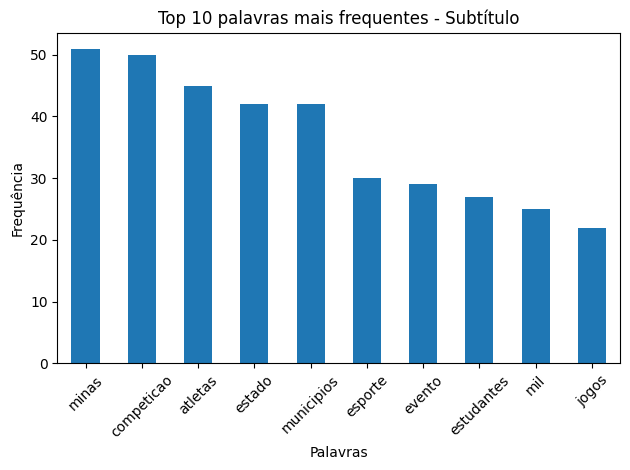

In [37]:
top10_subtitulo = frequencia_palavras.head(10)
top10_subtitulo.index = top10_subtitulo.index.str.replace('bow_sub_', '', regex=False)

import matplotlib.pyplot as plt

plt.figure()
top10_subtitulo.plot(kind='bar')

plt.title('Top 10 palavras mais frequentes - Subtítulo')
plt.xlabel('Palavras')
plt.ylabel('Frequência')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Palavras mais frequentes — Temas

Quais categorias de tema aparecem com mais frequência nas notícias de esporte coletadas?

In [38]:
colunas_bow_tema = [coluna for coluna in df_final_completo.columns if coluna.startswith("bow_tema_")]

frequencia_palavras = df_final_completo[colunas_bow_tema].sum().sort_values(ascending=False)

print(f"Total de palavras diferentes: {len(frequencia_palavras)}")

frequencia_palavras.head(10)

Total de palavras diferentes: 23


bow_tema_esportes          326
bow_tema_social            178
bow_tema_educacao           78
bow_tema_infraestrutura     35
bow_tema_governo            35
bow_tema_governador         23
bow_tema_cultura            22
bow_tema_seguranca          14
bow_tema_turismo            14
bow_tema_humanos             9
dtype: int64

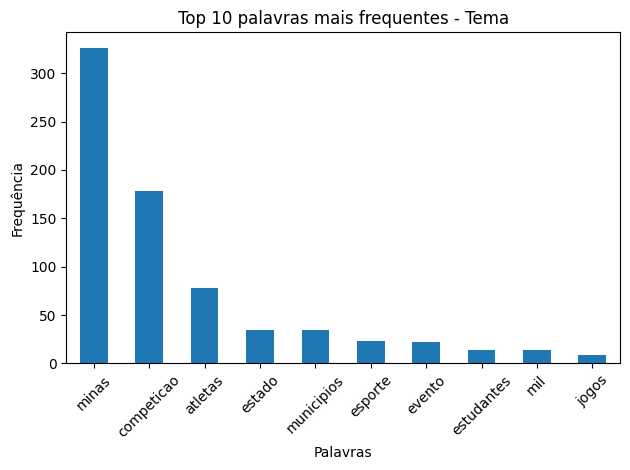

In [39]:
top10_tema = frequencia_palavras.head(10)
top10_tema.index = top10_subtitulo.index.str.replace('bow_tema_', '', regex=False)

import matplotlib.pyplot as plt

plt.figure()
top10_tema.plot(kind='bar')

plt.title('Top 10 palavras mais frequentes - Tema')
plt.xlabel('Palavras')
plt.ylabel('Frequência')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Salvando os dados

Por fim, salvamos os DataFrames gerados em arquivos CSV na pasta `data/`:

- `noticias.csv` — metadados e textos originais/limpos de cada notícia.
- `bow.csv` — metadados + Bag of Words de todas as colunas textuais.


In [40]:
from pathlib import Path

pasta_dados = Path("../../dados")
pasta_dados.mkdir(exist_ok=True)

# Dados completos: metadados + texto original e limpo
df_completo = df[[
    "url", "titulo", "subtitulo", "descricao", "temas", "data",
    "descricao_limpo", "descricao_sem_stopwords"
]]
df_completo.to_csv(pasta_dados / "noticias.csv", index=False)

# Bag of Words (metadados + colunas bow_desc_, bow_tit_, bow_sub_, bow_tema_)
df_final_completo.to_csv(pasta_dados / "bow.csv", index=False)

# TF-IDF (metadados + colunas tfidf_)
df_final_tfidf.to_csv(pasta_dados / "tfidf.csv", index=False)

print(f"Notícias completas: {pasta_dados / 'noticias.csv'} (shape={df_completo.shape})")
print(f"Bag of Words:       {pasta_dados / 'bow.csv'}      (shape={df_final_completo.shape})")
print(f"TF-IDF:             {pasta_dados / 'tfidf.csv'}    (shape={df_final_tfidf.shape})")


Notícias completas: ..\..\dados\noticias.csv (shape=(326, 8))
Bag of Words:       ..\..\dados\bow.csv      (shape=(326, 3556))
TF-IDF:             ..\..\dados\tfidf.csv    (shape=(326, 1333))
